# Линейная регрессия с разными функциями потерь

### 1. Подготовка данных с выбросами

In [1]:
# Импортируем бибилиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression

In [2]:
# Генерация базовых данных
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=50,
    random_state=42
)

In [3]:
# Преобразуем в DataFrame
X = pd.DataFrame(X, columns=['feature'])
y = pd.Series(y, name='target')

# Сохраним «чистую» версию 'y' для сравнения
y_clean = y.copy()

In [4]:
# Превратим в выбросы 5% объектов
n_outliers = int(0.05 * len(y))
outlier_indices = np.random.RandomState(42).choice(y.index, size=n_outliers, replace=False)
y.loc[outlier_indices] *= 5

<Axes: xlabel='feature', ylabel='target'>

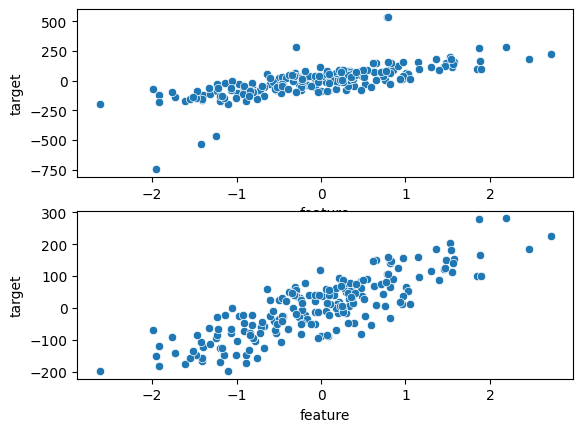

In [16]:
# Строим график разброса до и после добавления выбросов
plt.subplot(2, 1, 1)
df = X.assign(target=y)
sns.scatterplot(
    data=df,
    x='feature',
    y='target'
)

plt.subplot(2, 1, 2)
df_clean = X.assign(target=y_clean)
sns.scatterplot(
    data=df_clean,
    x='feature',
    y='target'
)